In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

import clmm

cosmo = clmm.Cosmology(
    H0=70.0,
    Omega_dm0=0.3 - 0.045,
    Omega_b0=0.045,
    Omega_k0=0.0,
)

In [12]:
# Redshift grid for evaluating source distributions and lensing kernels.
z_grid = np.linspace(0.001, 4.0, 2000)

# We simulate 20 tomographic source bins between z = 0.1 and z = 2.0.
n_bins = 20
z_min = 0.1
z_max = 2.0

z_edges = np.linspace(z_min, z_max, n_bins + 1)
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

print("Tomographic bin edges:")
for i in range(n_bins):
    print(f"bin {i+1}: {z_edges[i]:.3f} < z < {z_edges[i+1]:.3f}")

Tomographic bin edges:
bin 1: 0.100 < z < 0.195
bin 2: 0.195 < z < 0.290
bin 3: 0.290 < z < 0.385
bin 4: 0.385 < z < 0.480
bin 5: 0.480 < z < 0.575
bin 6: 0.575 < z < 0.670
bin 7: 0.670 < z < 0.765
bin 8: 0.765 < z < 0.860
bin 9: 0.860 < z < 0.955
bin 10: 0.955 < z < 1.050
bin 11: 1.050 < z < 1.145
bin 12: 1.145 < z < 1.240
bin 13: 1.240 < z < 1.335
bin 14: 1.335 < z < 1.430
bin 15: 1.430 < z < 1.525
bin 16: 1.525 < z < 1.620
bin 17: 1.620 < z < 1.715
bin 18: 1.715 < z < 1.810
bin 19: 1.810 < z < 1.905
bin 20: 1.905 < z < 2.000


In [13]:
def gaussian_nz(z, z0, sigma):
    """
    Gaussian source redshift distribution centered at z0.
    """
    return np.exp(-0.5 * ((z - z0) / sigma) ** 2)


# Choose a small width so the bins look like the "no photo-z error" case.
sigma_z = 0.03

n_of_z = np.zeros((n_bins, len(z_grid)))

for i, z0 in enumerate(z_centers):
    nz = gaussian_nz(z_grid, z0, sigma_z)

    # Remove support outside the main source range.
    nz[(z_grid < z_min) | (z_grid > z_max)] = 0.0

    # Normalize so integral n_i(z) dz = 1.
    norm = integrate.trapezoid(nz, z_grid)
    if norm > 0:
        nz = nz / norm

    n_of_z[i] = nz

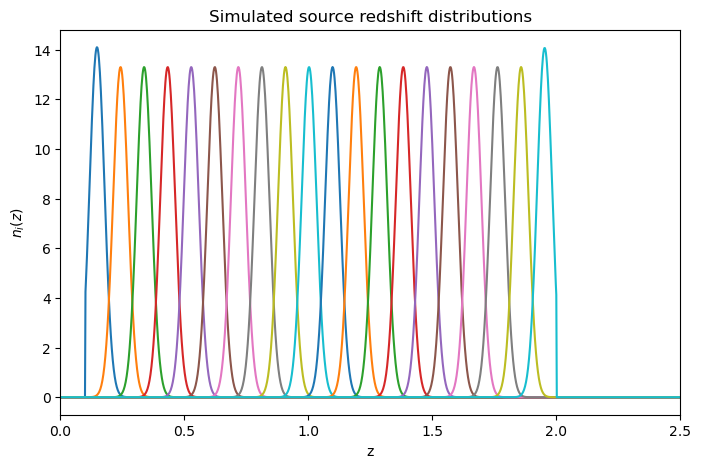

In [14]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, n_of_z[i])

plt.xlabel("z")
plt.ylabel(r"$n_i(z)$")
plt.title("Simulated source redshift distributions")
plt.xlim(0, 2.5)
plt.show()

In [15]:
def chi_of_z(z):
    """
    Convert redshift to comoving distance.

    CLMM eval_da returns angular diameter distance.
    For a flat universe, comoving distance is:
        chi(z) = D_A(z) * (1 + z)
    """
    return cosmo.eval_da(z) * (1.0 + z)


chi_grid = np.array([chi_of_z(z) for z in z_grid])

In [16]:
q = np.zeros_like(n_of_z)

for i in range(n_bins):
    for k, z_lens in enumerate(z_grid):
        chi_lens = chi_grid[k]

        # Only sources behind this lens redshift contribute.
        source_mask = chi_grid > chi_lens

        integrand = np.zeros_like(z_grid)
        integrand[source_mask] = (
            n_of_z[i, source_mask]
            * (chi_grid[source_mask] - chi_lens)
            / chi_grid[source_mask]
        )

        q[i, k] = chi_lens * integrate.trapezoid(integrand, z_grid)

    # Normalize each kernel peak to 1 for plotting.
    max_q = np.max(q[i])
    if max_q > 0:
        q[i] = q[i] / max_q

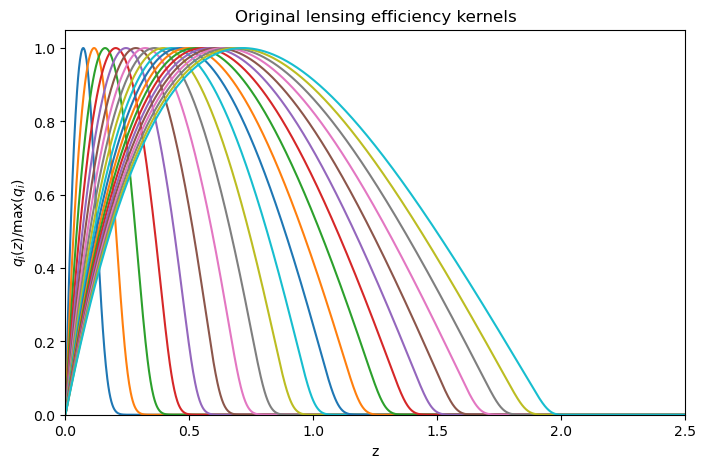

In [17]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, q[i])

plt.xlabel("z")
plt.ylabel(r"$q_i(z) / \max(q_i)$")
plt.title("Original lensing efficiency kernels")
plt.xlim(0, 2.5)
plt.ylim(0, 1.05)
plt.show()

In [18]:
B = np.zeros(n_bins)

for i in range(n_bins):
    inv_chi = np.zeros_like(z_grid)
    valid = chi_grid > 0
    inv_chi[valid] = 1.0 / chi_grid[valid]

    B[i] = integrate.trapezoid(n_of_z[i] * inv_chi, z_grid)

print("B coefficients:")
print(B)

B coefficients:
[0.00165029 0.00103638 0.00075733 0.00060412 0.00050729 0.00044064
 0.00039202 0.00035504 0.00032599 0.00030259 0.00028334 0.00026725
 0.00025359 0.00024187 0.00023168 0.00022277 0.00021489 0.00020788
 0.0002016  0.00019614]


In [19]:
def build_bnt_matrix_from_B(B):
    """
    Build the BNT matrix using the two nulling conditions:

        sum_j M_ij = 0

    and

        sum_j M_ij B_j = 0

    for each row i, using the three neighboring bins:
        i-2, i-1, i

    We set M_ii = 1 and solve for M_i,i-2 and M_i,i-1.
    """
    n = len(B)
    M = np.zeros((n, n))

    # First bin is left unchanged.
    M[0, 0] = 1.0

    # Second bin is a simple difference because true three-bin nulling
    # starts only from the third bin.
    M[1, 0] = -1.0
    M[1, 1] = 1.0

    for i in range(2, n):
        a = (B[i - 1] - B[i]) / (B[i - 2] - B[i - 1])
        b = -1.0 - a

        M[i, i - 2] = a
        M[i, i - 1] = b
        M[i, i] = 1.0

    return M


M = build_bnt_matrix_from_B(B)

print("BNT matrix shape:", M.shape)

BNT matrix shape: (20, 20)


In [20]:
q_tilde = M @ q

In [24]:
# Normalize the transformed kernels for plotting.
# We normalize by the largest absolute value in each kernel.
# This keeps the sign information and shows the true output
# of the BNT transformation.

q_tilde_norm = np.zeros_like(q_tilde)

for i in range(n_bins):
    max_abs = np.max(np.abs(q_tilde[i]))

    if max_abs > 0:
        q_tilde_norm[i] = q_tilde[i] / max_abs

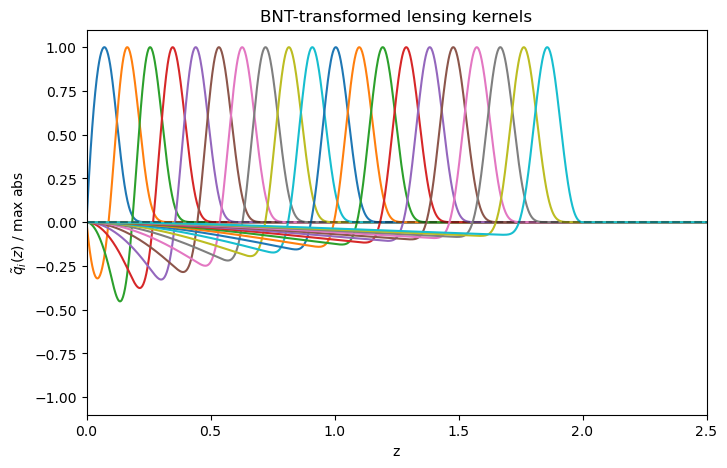

In [25]:
plt.figure(figsize=(8, 5))

for i in range(n_bins):
    plt.plot(z_grid, q_tilde_norm[i])

plt.xlabel("z")
plt.ylabel(r"$\tilde{q}_i(z)$ / max abs")
plt.title("BNT-transformed lensing kernels")

plt.xlim(0, 2.5)
plt.ylim(-1.1, 1.1)

plt.axhline(
    0,
    color="k",
    linestyle="--",
    alpha=0.4,
)

plt.show()

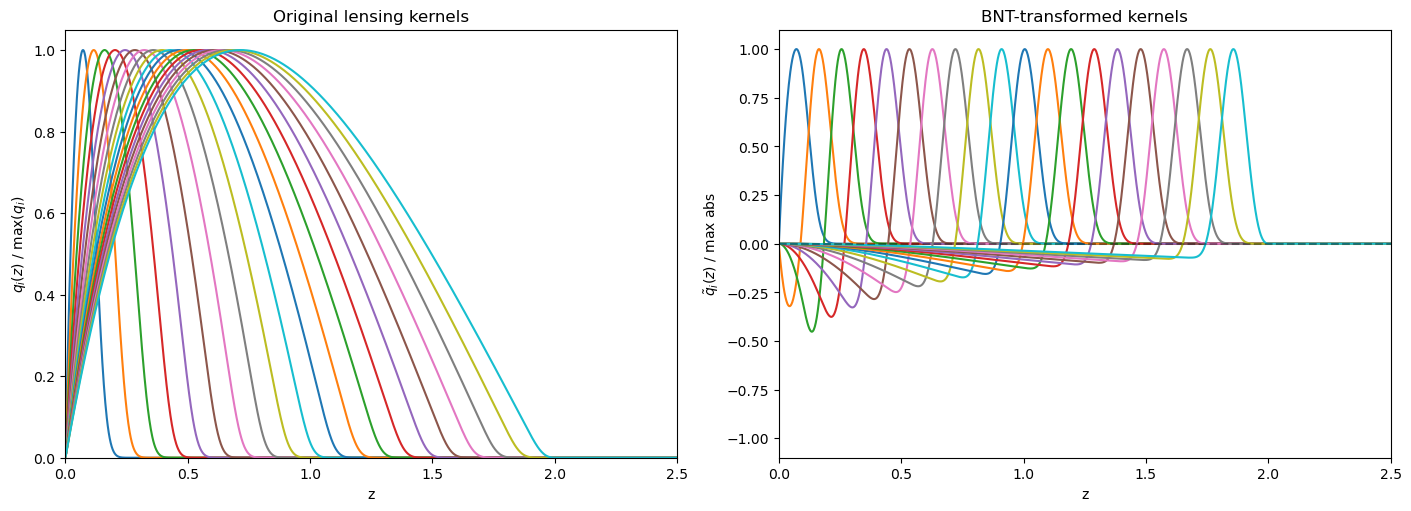

In [26]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    layout="constrained",
)

# Original kernels
for i in range(n_bins):
    axs[0].plot(z_grid, q[i])

axs[0].set_title("Original lensing kernels")
axs[0].set_xlabel("z")
axs[0].set_ylabel(r"$q_i(z)$ / max($q_i$)")
axs[0].set_xlim(0, 2.5)
axs[0].set_ylim(0, 1.05)

# Actual BNT-transformed kernels
for i in range(n_bins):
    axs[1].plot(z_grid, q_tilde_norm[i])

axs[1].set_title("BNT-transformed kernels")
axs[1].set_xlabel("z")
axs[1].set_ylabel(r"$\tilde{q}_i(z)$ / max abs")

axs[1].set_xlim(0, 2.5)
axs[1].set_ylim(-1.1, 1.1)

axs[1].axhline(
    0,
    color="k",
    linestyle="--",
    alpha=0.4,
)

plt.show()

Changes From Tuesday Afternoon: 
- Use 20 redshift distributions n_i(z) instead of 20 individual source planes
- Use comoving distance X(z) instead of redshift z directly
- Built BNT matrix using B_i coefficients: B_i = integral of n_i(z)/X(z)dz
- Matching more to the paper's method for the weak lensing kernels

Tuesday Afternoon: 
- Treated each source as a single galaxy/source plane at a specific redshift
- Used simplified kernel: q(z) = z(1 - (z/z_s))
- Built BNT matrix using 1/z

